# Sprint 2 — Feature Engineering + Experimentos A/B
## Detección de variaciones en el valor unitario · Exportaciones peruanas SUNAT

**Autor:** Said Leonardo Uceda Paredes &nbsp;|&nbsp; **Programa:** Maestría en IA — UNI &nbsp;|&nbsp; **Sprint 2 · Semana 5** &nbsp;|&nbsp; Mayo 2026

---
| # | Sección | Contenido |
|---|---------|----------|
| 1 | **Contexto** | Objetivo · Dataset · Métrica central |
| 2 | **EDA resumen** | 2 gráficos · 2 hallazgos · 1 riesgo (reutilizado de Sprint 1) |
| 3 | **Baseline** | IQR escala original · misma seed · mismo split |
| 4 | **Feature Engineering** | log1p · winsorización P5-P95 · ratio FOB/PESO |
| 5 | **Experimentos A/B** | Baseline (A) · Var1-log (B) · Var2-wins (C) |
| 6 | **Validación** | GroupKFold — grupos = subpartida |
| 7 | **Resultados** | Tabla comparativa · PR curve |
| 8 | **Reproducibilidad** | logs/metrics_experimentos.csv |
| 9 | **Conclusión** | Feature que más aportó · Decisión · Siguiente experimento |

---
## Sección 1 — Contexto

In [18]:
import logging
import warnings
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve,
)
from sqlalchemy import create_engine, text
from sqlalchemy.pool import NullPool

warnings.filterwarnings('ignore')

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
)
log = logging.getLogger('sprint2')

plt.rcParams.update({
    'figure.dpi'        : 120,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 10,
})

# ── Contexto del problema ──────────────────────────────────────────────────────
PROBLEMA      = 'Detección no supervisada de variaciones atípicas en el valor unitario (USD/kg) de exportaciones peruanas'
METRICA_CLAVE = 'F1-Score (clase outlier)'
METRICA_SEC   = 'PR-AUC, Precision, Recall'
SEED          = 42

# ── Parámetros de conexión ─────────────────────────────────────────────────────
SERVIDOR  = r'DESKTOP-OGU19A7\SQLEXPRESS,56878'
BASE_DATOS= 'DB_GEE_DW_ADUANAS'
ESQUEMA   = 'SC_ADUANA'
DRIVER    = 'ODBC+Driver+17+for+SQL+Server'
FEC_INI   = '2024-01-01'
FEC_FIN   = '2024-12-31'

# ── Columnas y umbrales ────────────────────────────────────────────────────────
COL_R        = 'NUM_SPN_R'
COL_C        = 'ANIO_C'
COL_V        = 'MTO_VALOR_UNTARIO_V'
UMBRAL_ANUAL = 36          # 3 reg/mes × 12 meses
CONTAM       = 0.05        # tasa de contaminación global

# ── Carpeta de logs ────────────────────────────────────────────────────────────
LOGS_DIR = Path('../../logs')
LOGS_DIR.mkdir(parents=True, exist_ok=True)
LOG_CSV  = LOGS_DIR / 'metrics_experimentos.csv'

print('CONTEXTO DEL SPRINT 2')
print('=' * 55)
print(f'  Problema      : {PROBLEMA}')
print(f'  Métrica clave : {METRICA_CLAVE}')
print(f'  Métricas sec. : {METRICA_SEC}')
print(f'  Seed          : {SEED}')
print(f'  Período datos : {FEC_INI} → {FEC_FIN}')
print(f'  Log CSV       : {LOG_CSV}')
log.info('Sprint 2 iniciado — %s', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

2026-05-08 18:44:31 | INFO | Sprint 2 iniciado — 2026-05-08 18:44:31


CONTEXTO DEL SPRINT 2
  Problema      : Detección no supervisada de variaciones atípicas en el valor unitario (USD/kg) de exportaciones peruanas
  Métrica clave : F1-Score (clase outlier)
  Métricas sec. : PR-AUC, Precision, Recall
  Seed          : 42
  Período datos : 2024-01-01 → 2024-12-31
  Log CSV       : ..\..\logs\metrics_experimentos.csv


---
## Sección 2 — EDA resumen *(reutilizado de Sprint 1)*
### 2.1 Carga de datos

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.1 CARGA DE DATOS DESDE SQL SERVER
# Fuente: SP_VALORES_UNITARIOS · ACCION = EDA_BASE
# ─────────────────────────────────────────────────────────────────────────────

from sqlalchemy import create_engine, text
from sqlalchemy.pool import NullPool
import pandas as pd
import numpy as np

url = (
    f'mssql+pyodbc://{SERVIDOR}/{BASE_DATOS}'
    f'?driver={DRIVER}&Trusted_Connection=yes'
)

try:
    motor = create_engine(
        url,
        echo=False,
        poolclass=NullPool
    )

    sentencia = text(
        f"EXEC [{BASE_DATOS}].[{ESQUEMA}].[SP_VALORES_UNITARIOS] "
        f"@ACCION='EDA_BASE', "
        f"@FEC_INI='{FEC_INI}', "
        f"@FEC_FIN='{FEC_FIN}'"
    )

    with motor.connect() as conn:
        resultado = conn.execute(sentencia)

        df = pd.DataFrame.from_records(
            resultado.fetchall(),
            columns=list(resultado.keys())
        )

except Exception as exc:
    raise RuntimeError(
        f'No se pudo conectar a SQL Server [{SERVIDOR}].\n'
        f'Ejecutar primero: python pruebas_mvp.py --prueba1\n'
        f'Detalle: {exc}'
    ) from exc

finally:
    try:
        motor.dispose()
    except NameError:
        pass


if df.empty:
    raise ValueError(
        'SP retornó 0 registros. Verificar INGESTA y rango de fechas.'
    )


# ── Dataset principal del notebook ───────────────────────────────────────────
df_model = df.copy()

print('df_model cargado correctamente desde SQL Server')
print('=' * 80)
print(f'Filas       : {len(df_model):,}')
print(f'Columnas    : {len(df_model.columns):,}')
print()
print(df_model.head())

log.info('df_model cargado desde SP_VALORES_UNITARIOS: %s filas', len(df_model))



# ─────────────────────────────────────────────────────────────────────────────
# VALIDACIÓN DE COLUMNAS BASE
# ─────────────────────────────────────────────────────────────────────────────

columnas_requeridas = [
    'NUM_SPN_R',
    'ADUANA',
    'FOB_DOLAR',
    COL_V
]

faltantes = [
    col for col in columnas_requeridas
    if col not in df_model.columns
]

if faltantes:
    raise ValueError(f'Columnas faltantes en df_model: {faltantes}')

df_model['FOB_DOLAR'] = pd.to_numeric(
    df_model['FOB_DOLAR'],
    errors='coerce'
)

df_model[COL_V] = pd.to_numeric(
    df_model[COL_V],
    errors='coerce'
)

df_model = df_model.dropna(
    subset=[
        'NUM_SPN_R',
        'ADUANA',
        'FOB_DOLAR',
        COL_V
    ]
).copy()

df_model = df_model[
    (df_model['FOB_DOLAR'] > 0) &
    (df_model[COL_V] > 0)
].copy()

print('Columnas base validadas correctamente')
print('=' * 80)
print(f'Registros válidos      : {len(df_model):,}')
print(f'Subpartidas distintas  : {df_model["NUM_SPN_R"].nunique():,}')
print(f'Aduanas distintas      : {df_model["ADUANA"].nunique():,}')
print(f'FOB_DOLAR total        : {df_model["FOB_DOLAR"].sum():,.2f}')


2026-05-08 18:45:15 | INFO | df_model cargado desde SP_VALORES_UNITARIOS: 390426 filas


df_model cargado correctamente desde SQL Server
Filas       : 390,426
Columnas    : 8

   ANIO_C                                          NUM_SPN_R  \
0    2024  2005700000-ACEITUNAS PREPARADAS O CONSERVADAS,...   
1    2024                   804200000-HIGOS, FRESCOS O SECOS   
2    2024         1008509000-QUINUA, EXCEPTO PARA LA SIEMBRA   
3    2024         1008509000-QUINUA, EXCEPTO PARA LA SIEMBRA   
4    2024  810400000-ARANDANOS ROJOS, MIRTILOS Y DEMAS FR...   

  MTO_VALOR_UNTARIO_V  FOB_DOLAR  PESO_NETO SECTOR  \
0            3.649023   3773.090   1034.000    500   
1           10.829752  10483.200    968.000    500   
2            2.742683  54853.660  20000.000    500   
3            1.179902  23598.040  20000.000    500   
4           11.333333   4080.000    360.000    500   

                     TIPO_PRODUCTO                    ADUANA  
0  02 - PRODUCTOS NO TRADICIONALES       MARITIMA DEL CALLAO  
1  02 - PRODUCTOS NO TRADICIONALES  AEREA Y POSTAL EX - IAAC  
2  02 - PRODUC

### 2.2 Gráfico 1 — Distribución del VU (hallazgo: sesgo derecho)

TOP 2 subpartidas por mayor movimiento en FOB_DOLAR
                                       NUM_SPN_R  FOB_DOLAR_TOTAL  REGISTROS
2603000000-MINERALES DE COBRE Y SUS CONCENTRADOS     1.548788e+10       1297
     7108120000-ORO EN LAS DEMAS FORMAS EN BRUTO     1.092524e+10      14491


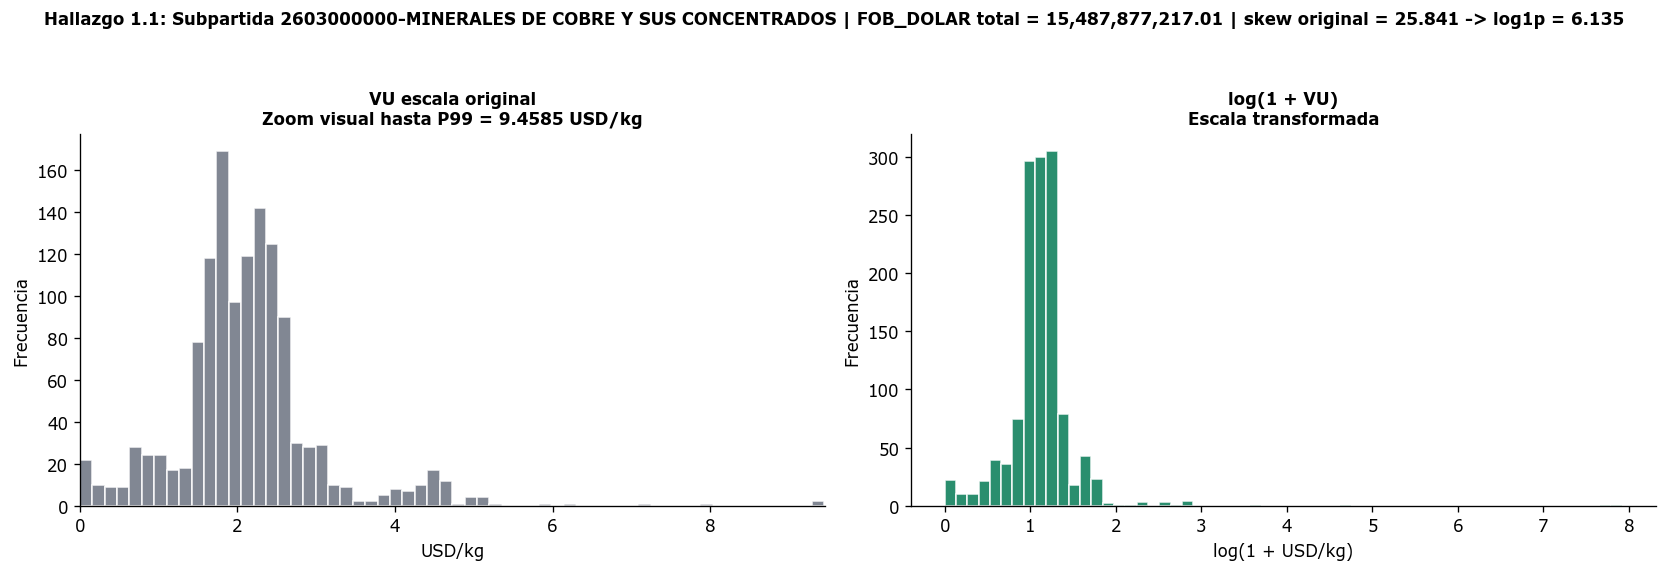

2026-05-08 18:47:31 | INFO | Gráfico 1 guardado: fig_s2_distribucion_top_1_2603000000-MINERALES DE COBRE Y SUS CONCENTRADOS.png



ANÁLISIS — Subpartida 2603000000-MINERALES DE COBRE Y SUS CONCENTRADOS
Ranking por FOB_DOLAR             : Top 1
FOB_DOLAR total                   : 15,487,877,217.01
Registros totales subpartida      : 1,297
Registros usados con MTO_VALOR_UNTARIO_V > 0  : 1,297
Variable graficada en USD/kg      : MTO_VALOR_UNTARIO_V
--------------------------------------------------------------------------------
VU mínimo                         : 0.0000
VU P01                            : 0.0048
VU P05                            : 0.7026
VU P25                            : 1.7015
VU mediana                        : 2.0835
VU media                          : 6.1381
VU P75                            : 2.4839
VU P95                            : 4.3055
VU P99                            : 9.4585
VU máximo                         : 2,752.4392
--------------------------------------------------------------------------------
Skew original                     : 25.841
Skew log1p                        : 6.135

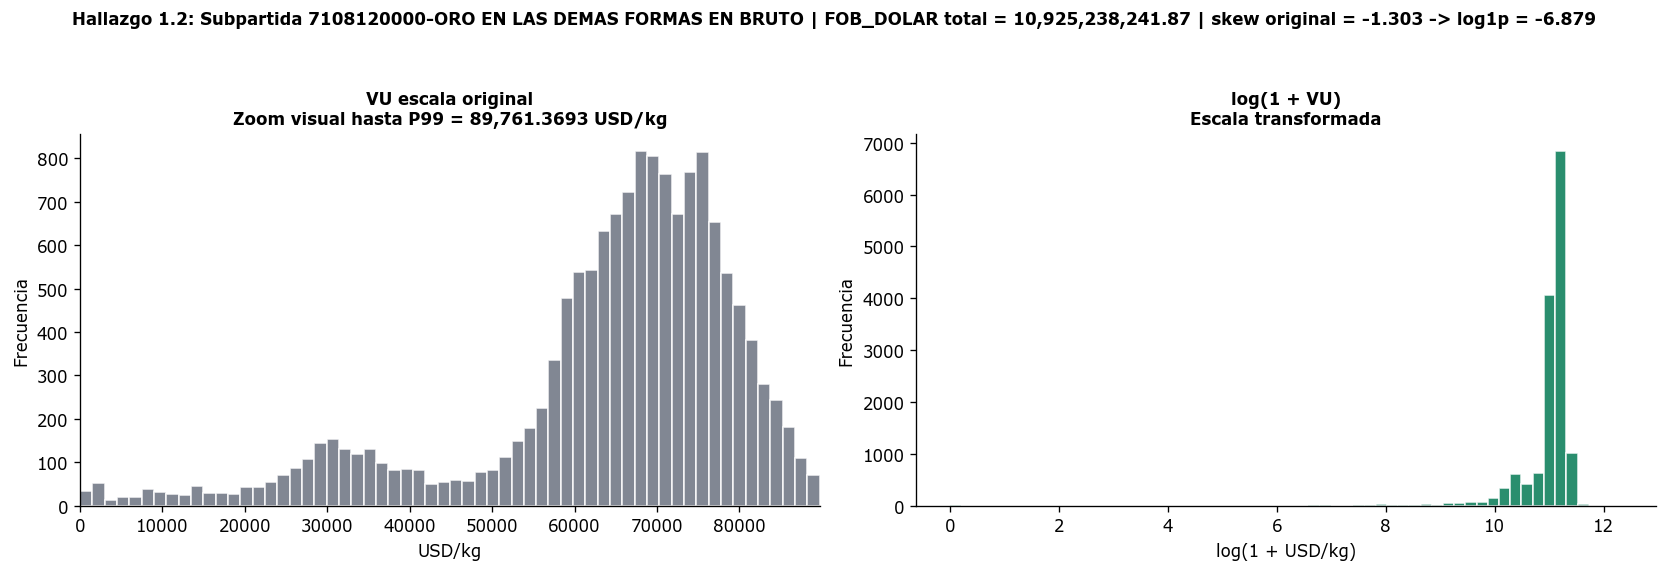

2026-05-08 18:47:32 | INFO | Gráfico 1 guardado: fig_s2_distribucion_top_2_7108120000-ORO EN LAS DEMAS FORMAS EN BRUTO.png



ANÁLISIS — Subpartida 7108120000-ORO EN LAS DEMAS FORMAS EN BRUTO
Ranking por FOB_DOLAR             : Top 2
FOB_DOLAR total                   : 10,925,238,241.87
Registros totales subpartida      : 14,491
Registros usados con MTO_VALOR_UNTARIO_V > 0  : 14,491
Variable graficada en USD/kg      : MTO_VALOR_UNTARIO_V
--------------------------------------------------------------------------------
VU mínimo                         : 0.0002
VU P01                            : 7,861.4682
VU P05                            : 27,504.0915
VU P25                            : 59,735.6529
VU mediana                        : 68,213.7733
VU media                          : 64,294.3958
VU P75                            : 75,262.0150
VU P95                            : 83,913.6875
VU P99                            : 89,761.3693
VU máximo                         : 229,880.1850
--------------------------------------------------------------------------------
Skew original                     : -1.303
Ske

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.2 GRÁFICO 1 — Distribución del VU
# Análisis por las 2 subpartidas con mayor movimiento en FOB_DOLAR
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ── Validación de variables base ──────────────────────────────────────────────
# COL_V debe representar el valor unitario en USD/kg.
# Ejemplo esperado:
# COL_V = 'VU'
if 'COL_V' not in globals():
    raise NameError("La variable COL_V no existe. Define primero: COL_V = 'VU'")

if 'df_model' not in globals():
    raise NameError("El DataFrame df_model no existe. Verifica el nombre de tu DataFrame principal.")


# ── Validación de columnas requeridas ─────────────────────────────────────────
columnas_requeridas = [
    'NUM_SPN_R',
    'FOB_DOLAR',
    COL_V
]

faltantes = [col for col in columnas_requeridas if col not in df_model.columns]

if faltantes:
    raise ValueError(f'Columnas faltantes en df_model: {faltantes}')


# ── Limpieza mínima para evitar errores de tipo ───────────────────────────────
df_grafico = df_model.copy()

df_grafico['FOB_DOLAR'] = pd.to_numeric(
    df_grafico['FOB_DOLAR'],
    errors='coerce'
)

df_grafico[COL_V] = pd.to_numeric(
    df_grafico[COL_V],
    errors='coerce'
)


# ── 1. Identificar las 2 subpartidas con mayor movimiento FOB_DOLAR ───────────
top_subpartidas = (
    df_grafico
    .dropna(subset=['NUM_SPN_R', 'FOB_DOLAR'])
    .groupby('NUM_SPN_R', as_index=False)
    .agg(
        FOB_DOLAR_TOTAL=('FOB_DOLAR', 'sum'),
        REGISTROS=('NUM_SPN_R', 'size')
    )
    .sort_values('FOB_DOLAR_TOTAL', ascending=False)
    .head(2)
)

print('TOP 2 subpartidas por mayor movimiento en FOB_DOLAR')
print('=' * 80)
print(top_subpartidas.to_string(index=False))


# ── 2. Graficar VU original vs log1p(VU) para cada subpartida ─────────────────
for posicion, fila in enumerate(top_subpartidas.itertuples(index=False), start=1):

    num_spn_r = fila.NUM_SPN_R
    fob_total = fila.FOB_DOLAR_TOTAL
    registros_total = fila.REGISTROS

    df_spn = df_grafico[df_grafico['NUM_SPN_R'] == num_spn_r].copy()

    # Variable del eje USD/kg.
    # Esta variable debe ser el valor unitario:
    # VU = FOB_DOLAR / PESO_NETO_KG
    datos = df_spn[COL_V].dropna()
    datos = datos[datos > 0]

    if datos.empty:
        print()
        print(f'Subpartida {num_spn_r} omitida: no tiene valores positivos en {COL_V}.')
        continue

    # ── Estadísticos principales ──────────────────────────────────────────────
    skew_orig = round(datos.skew(), 3)
    skew_log = round(np.log1p(datos).skew(), 3)

    min_orig = datos.min()
    p01_orig = datos.quantile(0.01)
    p05_orig = datos.quantile(0.05)
    p25_orig = datos.quantile(0.25)
    mediana_orig = datos.median()
    media_orig = datos.mean()
    p75_orig = datos.quantile(0.75)
    p95_orig = datos.quantile(0.95)
    p99_orig = datos.quantile(0.99)
    max_orig = datos.max()

    # ── Zoom visual para la escala original ───────────────────────────────────
    # No modifica el análisis, solo evita que pocos extremos aplasten el histograma.
    datos_visual = datos[datos <= p99_orig]

    registros_visual = len(datos_visual)
    registros_excluidos_visual = len(datos) - registros_visual
    pct_visual = registros_visual / len(datos)

    # ── Gráfico ───────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    # A: VU original con zoom visual hasta P99
    axes[0].hist(
        datos_visual,
        bins=60,
        color='#6b7280',
        edgecolor='white',
        alpha=0.85
    )

    axes[0].set_xlim(0, p99_orig)

    axes[0].set_title(
        f'VU escala original\nZoom visual hasta P99 = {p99_orig:,.4f} USD/kg',
        fontweight='bold'
    )

    axes[0].set_xlabel('USD/kg')
    axes[0].set_ylabel('Frecuencia')

    # B: log1p(VU)
    axes[1].hist(
        np.log1p(datos),
        bins=60,
        color='#057a55',
        edgecolor='white',
        alpha=0.85
    )

    axes[1].set_title(
        'log(1 + VU)\nEscala transformada',
        fontweight='bold'
    )

    axes[1].set_xlabel('log(1 + USD/kg)')
    axes[1].set_ylabel('Frecuencia')

    # Título general
    plt.suptitle(
        (
            f'Hallazgo 1.{posicion}: Subpartida {num_spn_r} | '
            f'FOB_DOLAR total = {fob_total:,.2f} | '
            f'skew original = {skew_orig} -> log1p = {skew_log}'
        ),
        fontsize=10,
        fontweight='bold',
        y=1.05
    )

    plt.tight_layout()

    # Nombre de archivo seguro
    nombre_archivo = f'fig_s2_distribucion_top_{posicion}_{str(num_spn_r).replace("/", "_")}.png'

    plt.savefig(
        nombre_archivo,
        dpi=120,
        bbox_inches='tight'
    )

    plt.show()

    # ── Análisis actualizado ──────────────────────────────────────────────────
    print()
    print(f'ANÁLISIS — Subpartida {num_spn_r}')
    print('=' * 80)
    print(f'Ranking por FOB_DOLAR             : Top {posicion}')
    print(f'FOB_DOLAR total                   : {fob_total:,.2f}')
    print(f'Registros totales subpartida      : {registros_total:,}')
    print(f'Registros usados con {COL_V} > 0  : {len(datos):,}')
    print(f'Variable graficada en USD/kg      : {COL_V}')
    print('-' * 80)
    print(f'VU mínimo                         : {min_orig:,.4f}')
    print(f'VU P01                            : {p01_orig:,.4f}')
    print(f'VU P05                            : {p05_orig:,.4f}')
    print(f'VU P25                            : {p25_orig:,.4f}')
    print(f'VU mediana                        : {mediana_orig:,.4f}')
    print(f'VU media                          : {media_orig:,.4f}')
    print(f'VU P75                            : {p75_orig:,.4f}')
    print(f'VU P95                            : {p95_orig:,.4f}')
    print(f'VU P99                            : {p99_orig:,.4f}')
    print(f'VU máximo                         : {max_orig:,.4f}')
    print('-' * 80)
    print(f'Skew original                     : {skew_orig}')
    print(f'Skew log1p                        : {skew_log}')
    print(f'Registros visibles hasta P99      : {registros_visual:,} ({pct_visual:.2%})')
    print(f'Registros fuera del zoom visual   : {registros_excluidos_visual:,}')
    print('-' * 80)

    if skew_orig > 1:
        print('Interpretación original           : distribución con cola derecha pronunciada.')
    elif skew_orig < -1:
        print('Interpretación original           : distribución con cola izquierda pronunciada.')
    else:
        print('Interpretación original           : distribución relativamente simétrica.')

    if abs(skew_log) < abs(skew_orig):
        print('Efecto log1p                      : la transformación reduce la asimetría.')
    else:
        print('Efecto log1p                      : la transformación no reduce la asimetría en este grupo.')

    print('Nota visual                       : la escala original usa zoom hasta P99 solo para visualizar mejor la masa principal.')
    print('Importante                        : el cálculo de skew, media, mediana y percentiles usa todos los datos positivos.')
    print(f'Gráfico guardado                  : {nombre_archivo}')

    try:
        log.info(f'Gráfico 1 guardado: {nombre_archivo}')
    except NameError:
        pass

### 2.3 Gráfico 2 — Top 10 subpartidas + riesgo desbalance

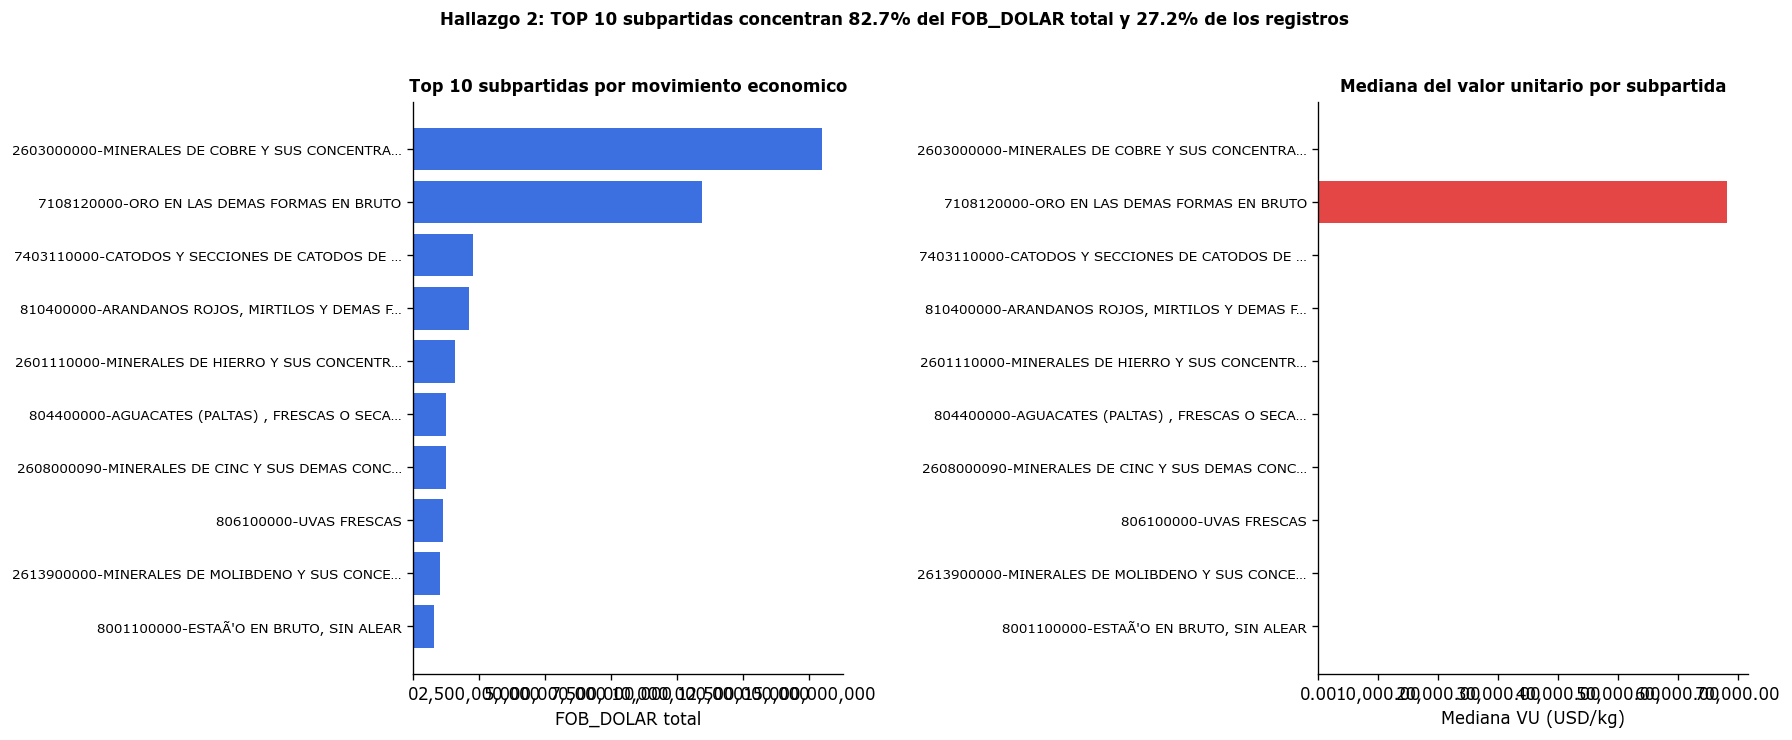

2026-05-08 18:48:23 | INFO | Gráfico 2 guardado: fig_s2_top10.png


TOP 10 subpartidas por movimiento economico (FOB_DOLAR)
                                                                                  FOB_DOLAR_TOTAL      N  Mediana_VU
NUM_SPN_R                                                                                                           
2603000000-MINERALES DE COBRE Y SUS CONCENTRADOS                                     1.548788e+10   1297       2.084
7108120000-ORO EN LAS DEMAS FORMAS EN BRUTO                                          1.092524e+10  14491   68213.773
7403110000-CATODOS Y SECCIONES DE CATODOS DE COBRE REFINADO                          2.270523e+09    948       9.312
810400000-ARANDANOS ROJOS, MIRTILOS Y DEMAS FRUTOS DEL GENERO VACCINIUM, FRESCOS     2.103763e+09  27373       7.133
2601110000-MINERALES DE HIERRO Y SUS CONCENTRADOS, SIN AGLOMERAR                     1.564171e+09    468       0.073
804400000-AGUACATES (PALTAS) , FRESCAS O SECAS                                       1.241846e+09  34213       2.210
26080000

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# GRÁFICO 2: concentración por movimiento económico
# TOP 10 subpartidas por FOB_DOLAR + mediana de VU
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.ticker as mticker
import pandas as pd

# ── Validación de variables base ──────────────────────────────────────────────
if 'COL_R' not in globals():
    raise NameError("La variable COL_R no existe. Define la columna de subpartida o descripcion.")

if 'COL_V' not in globals():
    raise NameError("La variable COL_V no existe. Define primero: COL_V = 'VU'")

if 'df_model' not in globals():
    raise NameError("El DataFrame df_model no existe.")

columnas_requeridas = [COL_R, 'FOB_DOLAR', COL_V]

faltantes = [col for col in columnas_requeridas if col not in df_model.columns]
if faltantes:
    raise ValueError(f'Columnas faltantes en df_model: {faltantes}')


# ── Preparación de datos ──────────────────────────────────────────────────────
df_grafico = df_model.copy()

df_grafico['FOB_DOLAR'] = pd.to_numeric(df_grafico['FOB_DOLAR'], errors='coerce')
df_grafico[COL_V] = pd.to_numeric(df_grafico[COL_V], errors='coerce')

# Solo para la mediana de VU conviene usar VU positivo
df_grafico_vu = df_grafico[df_grafico[COL_V] > 0].copy()


# ── TOP 10 subpartidas por movimiento FOB_DOLAR ───────────────────────────────
top10 = (
    df_grafico
    .dropna(subset=[COL_R, 'FOB_DOLAR'])
    .groupby(COL_R, as_index=True)
    .agg(
        FOB_DOLAR_TOTAL=('FOB_DOLAR', 'sum'),
        N=('FOB_DOLAR', 'size')
    )
    .join(
        df_grafico_vu
        .dropna(subset=[COL_R, COL_V])
        .groupby(COL_R)[COL_V]
        .median()
        .rename('Mediana_VU'),
        how='left'
    )
    .round(3)
    .sort_values('FOB_DOLAR_TOTAL', ascending=False)
    .head(10)
)

# Para que el mayor quede arriba en barh
top10_plot = top10.sort_values('FOB_DOLAR_TOTAL', ascending=True).copy()

etqs = [
    s[:45] + '…' if isinstance(s, str) and len(s) > 45 else str(s)
    for s in top10_plot.index
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

y = range(len(top10_plot))

# ── Panel 1: TOP 10 por movimiento FOB_DOLAR ─────────────────────────────────
axes[0].barh(
    y,
    top10_plot['FOB_DOLAR_TOTAL'],
    color='#1a56db',
    alpha=0.85
)
axes[0].set_yticks(y)
axes[0].set_yticklabels(etqs, fontsize=8)
axes[0].set_xlabel('FOB_DOLAR total')
axes[0].set_title('Top 10 subpartidas por movimiento economico', fontweight='bold')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

# ── Panel 2: Mediana de VU para esas mismas subpartidas ──────────────────────
axes[1].barh(
    y,
    top10_plot['Mediana_VU'],
    color='#e02424',
    alpha=0.85
)
axes[1].set_yticks(y)
axes[1].set_yticklabels(etqs, fontsize=8)
axes[1].set_xlabel('Mediana VU (USD/kg)')
axes[1].set_title('Mediana del valor unitario por subpartida', fontweight='bold')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.2f}')
)

# ── Indicadores de concentración ──────────────────────────────────────────────
fob_total_dataset = df_grafico['FOB_DOLAR'].sum()
fob_top10 = top10['FOB_DOLAR_TOTAL'].sum()
pct_top10_fob = 100 * fob_top10 / fob_total_dataset if fob_total_dataset > 0 else 0

n_total_registros = len(df_grafico)
n_top10_registros = top10['N'].sum()
pct_top10_registros = 100 * n_top10_registros / n_total_registros if n_total_registros > 0 else 0

plt.suptitle(
    (
        f'Hallazgo 2: TOP 10 subpartidas concentran '
        f'{pct_top10_fob:.1f}% del FOB_DOLAR total '
        f'y {pct_top10_registros:.1f}% de los registros'
    ),
    fontsize=10,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig('fig_s2_top10.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Resumen impreso ───────────────────────────────────────────────────────────
print('TOP 10 subpartidas por movimiento economico (FOB_DOLAR)')
print('=' * 90)
print(top10.to_string())

print()
print(f'Riesgo identificado              : CONCENTRACION / DESBALANCE')
print(f'TOP 10 FOB_DOLAR total           : {fob_top10:,.2f}')
print(f'FOB_DOLAR total del dataset      : {fob_total_dataset:,.2f}')
print(f'TOP 10 concentran FOB_DOLAR      : {pct_top10_fob:.1f}%')
print(f'TOP 10 concentran registros      : {pct_top10_registros:.1f}%')
print('Interpretacion                   : pocas subpartidas concentran gran parte del movimiento economico.')
print('Implicancia                      : una contaminacion global fija puede no representar bien subpartidas pequenas.')
print('Recomendacion                    : evaluar por subpartida y revisar umbrales/contamination por grupo.')

log.info('Gráfico 2 guardado: fig_s2_top10.png')

---
## Sección 3 — Baseline

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# DATASET DE EVALUACIÓN REAL CON ETIQUETA PROXY
# Objetivo:
#   Construir df_eval desde df_model real.
#   La etiqueta _gt es una referencia estadística, no ground truth oficial.
# ─────────────────────────────────────────────────────────────────────────────

columnas_requeridas = [
    'NUM_SPN_R',
    'ADUANA',
    'FOB_DOLAR',
    COL_V
]

faltantes = [
    col for col in columnas_requeridas
    if col not in df_model.columns
]

if faltantes:
    raise ValueError(f'Columnas faltantes para df_eval real: {faltantes}')


df_eval = df_model[columnas_requeridas].copy()

df_eval['VU'] = pd.to_numeric(
    df_eval[COL_V],
    errors='coerce'
)

df_eval['FOB_DOLAR'] = pd.to_numeric(
    df_eval['FOB_DOLAR'],
    errors='coerce'
)

df_eval = df_eval.dropna(
    subset=[
        'NUM_SPN_R',
        'ADUANA',
        'FOB_DOLAR',
        'VU'
    ]
).copy()

df_eval = df_eval[
    (df_eval['FOB_DOLAR'] > 0) &
    (df_eval['VU'] > 0)
].copy()

# ── Mantener subpartidas con mínimo de registros ─────────────────────────────
conteo_subpartida = df_eval.groupby('NUM_SPN_R')['VU'].transform('size')

df_eval = df_eval[
    conteo_subpartida >= UMBRAL_ANUAL
].copy()

# ── Etiqueta proxy extrema por subpartida ────────────────────────────────────
# Esta etiqueta permite comparar variantes.
# No representa una validación oficial de outlier.
q01 = df_eval.groupby('NUM_SPN_R')['VU'].transform(
    lambda x: x.quantile(0.01)
)

q99 = df_eval.groupby('NUM_SPN_R')['VU'].transform(
    lambda x: x.quantile(0.99)
)

df_eval['_gt'] = (
    (df_eval['VU'] < q01) |
    (df_eval['VU'] > q99)
).astype(int)

print('df_eval real creado correctamente')
print('=' * 80)
print(f'Registros                 : {len(df_eval):,}')
print(f'Subpartidas               : {df_eval["NUM_SPN_R"].nunique():,}')
print(f'Aduanas                   : {df_eval["ADUANA"].nunique():,}')
print(f'Outliers proxy _gt        : {df_eval["_gt"].sum():,}')
print(f'Tasa outlier proxy        : {100 * df_eval["_gt"].mean():.2f}%')
print()
print('Nota: _gt es una etiqueta proxy estadística, no ground truth oficial validado por experto.')

log.info('df_eval real creado: %s filas', len(df_eval))

2026-05-08 18:49:43 | INFO | df_eval real creado: 386491 filas


df_eval real creado correctamente
Registros                 : 386,491
Subpartidas               : 371
Aduanas                   : 16
Outliers proxy _gt        : 7,602
Tasa outlier proxy        : 1.97%

Nota: _gt es una etiqueta proxy estadística, no ground truth oficial validado por experto.


---
## Sección 4 — Feature Engineering
**Regla:** fit solo en train → apply en val/test · 1 cambio por experimento

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE ENGINEERING SOBRE df_eval REAL
# ─────────────────────────────────────────────────────────────────────────────

df_eval['VU_LOG'] = np.log1p(df_eval['VU'])

p5_por_grupo = df_eval.groupby('NUM_SPN_R')['VU'].transform(
    lambda x: x.quantile(0.05)
)

p95_por_grupo = df_eval.groupby('NUM_SPN_R')['VU'].transform(
    lambda x: x.quantile(0.95)
)

df_eval['VU_WINS'] = df_eval['VU'].clip(
    lower=p5_por_grupo,
    upper=p95_por_grupo
)

mediana_g = df_eval.groupby('NUM_SPN_R')['VU'].transform('median')

mad_g = df_eval.groupby('NUM_SPN_R')['VU'].transform(
    lambda x: (x - x.median()).abs().median()
)

df_eval['VU_ZSCORE_ROB'] = (
    (df_eval['VU'] - mediana_g) /
    (mad_g + 1e-9)
)

print('FEATURE ENGINEERING APLICADO SOBRE df_eval REAL')
print('=' * 80)
print(f'VU_LOG        : log1p(VU) | skew = {df_eval["VU_LOG"].skew():.3f}')
print('VU_WINS       : clip P5-P95 por subpartida')
print('VU_ZSCORE_ROB : mediana y MAD por subpartida')

log.info('Feature Engineering completado sobre df_eval real')

2026-05-08 18:50:13 | INFO | Feature Engineering completado sobre df_eval real


FEATURE ENGINEERING APLICADO SOBRE df_eval REAL
VU_LOG        : log1p(VU) | skew = 3.653
VU_WINS       : clip P5-P95 por subpartida
VU_ZSCORE_ROB : mediana y MAD por subpartida


## Sección 5 — Experimentos A/B

En esta sección se comparan variantes del método de detección de valores unitarios atípicos. La comparación se realiza bajo la lógica de experimento A/B: cada variante incorpora un único cambio respecto al baseline, manteniendo el mismo dataset, la misma semilla y la misma métrica de evaluación.

| Config | Cambio respecto al baseline | Descripción |
|--------|-----------------------------|-------------|
| **A — Baseline** | Ninguno | IQR sobre `VU` original por subpartida |
| **B — Var1** | Transformación | IQR sobre `log1p(VU)` |
| **C — Var2** | Preprocesamiento | IQR sobre `VU` winsorizado P5-P95 |
| **D — Var3** | Modelo | Isolation Forest sobre `log1p(VU)` |

La variante A representa la regla estadística base. Las variantes B y C evalúan si una transformación o preprocesamiento mejora la detección. La variante D incorpora un modelo de detección de anomalías para comparar si una técnica de Machine Learning supera al baseline estadístico.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECCIÓN 5 — EXPERIMENTOS A/B
# Comparación de variantes sobre df_eval real
#
# A — Baseline : IQR sobre VU original
# B — Var1     : IQR sobre log1p(VU)
# C — Var2     : IQR sobre VU winsorizado P5-P95
# D — Var3     : Isolation Forest sobre log1p(VU)
# ─────────────────────────────────────────────────────────────────────────────

import time
import numpy as np
import pandas as pd

from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, precision_score, recall_score


def predecir_iqr_por_grupo(
    serie: pd.Series,
    grupos: pd.Series
) -> np.ndarray:
    """
    Detecta outliers usando la regla IQR dentro de cada grupo.

    Args:
        serie (pd.Series): Valores numéricos que serán evaluados.
        grupos (pd.Series): Variable de agrupación. En este caso, NUM_SPN_R.

    Returns:
        np.ndarray: Vector binario donde 1 indica outlier y 0 indica normal.
    """
    tmp = pd.DataFrame({
        'valor': serie,
        'grupo': grupos
    }).copy()

    q1 = tmp.groupby('grupo')['valor'].transform(
        lambda x: x.quantile(0.25)
    )

    q3 = tmp.groupby('grupo')['valor'].transform(
        lambda x: x.quantile(0.75)
    )

    iqr = q3 - q1

    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr

    pred = (
        (tmp['valor'] < limite_inf) |
        (tmp['valor'] > limite_sup)
    ).astype(int)

    return pred.values


# ── Validación de columnas requeridas ─────────────────────────────────────────
columnas_requeridas = [
    'NUM_SPN_R',
    'ADUANA',
    'VU',
    'VU_LOG',
    'VU_WINS',
    'VU_ZSCORE_ROB',
    '_gt'
]

faltantes = [
    col for col in columnas_requeridas
    if col not in df_eval.columns
]

if faltantes:
    raise ValueError(f'Columnas faltantes en df_eval: {faltantes}')


# ─────────────────────────────────────────────────────────────────────────────
# A — BASELINE: IQR sobre VU original
# ─────────────────────────────────────────────────────────────────────────────
t0 = time.perf_counter()

pred_a = predecir_iqr_por_grupo(
    serie=df_eval['VU'],
    grupos=df_eval['NUM_SPN_R']
)

t_a = round((time.perf_counter() - t0) * 1000, 2)


# ─────────────────────────────────────────────────────────────────────────────
# B — VAR1: IQR sobre log1p(VU)
# ─────────────────────────────────────────────────────────────────────────────
t0 = time.perf_counter()

pred_b = predecir_iqr_por_grupo(
    serie=df_eval['VU_LOG'],
    grupos=df_eval['NUM_SPN_R']
)

t_b = round((time.perf_counter() - t0) * 1000, 2)


# ─────────────────────────────────────────────────────────────────────────────
# C — VAR2: IQR sobre VU winsorizado P5-P95
# ─────────────────────────────────────────────────────────────────────────────
t0 = time.perf_counter()

pred_c = predecir_iqr_por_grupo(
    serie=df_eval['VU_WINS'],
    grupos=df_eval['NUM_SPN_R']
)

t_c = round((time.perf_counter() - t0) * 1000, 2)


# ─────────────────────────────────────────────────────────────────────────────
# D — VAR3: Isolation Forest sobre log1p(VU)
# El modelo se entrena por subpartida para respetar la escala propia del producto.
# ─────────────────────────────────────────────────────────────────────────────
t0 = time.perf_counter()

pred_d = np.zeros(len(df_eval), dtype=int)

for num_spn_r, df_spn in df_eval.groupby('NUM_SPN_R'):

    filas = df_spn['VU_LOG'].dropna()

    if len(filas) < 10:
        continue

    modelo_if = IsolationForest(
        contamination=CONTAM,
        random_state=SEED
    )

    pred_if = modelo_if.fit_predict(
        filas.values.reshape(-1, 1)
    )

    pred_d[filas.index] = (pred_if == -1).astype(int)

t_d = round((time.perf_counter() - t0) * 1000, 2)


# ─────────────────────────────────────────────────────────────────────────────
# Métricas comparativas
# Nota:
#   _gt es una etiqueta proxy estadística, no ground truth oficial.
# ─────────────────────────────────────────────────────────────────────────────
y_true = df_eval['_gt'].values

resultados_ab = []

for nombre, descripcion, pred, tiempo_ms in [
    (
        'A_IQR_orig',
        'Baseline: IQR sobre VU original',
        pred_a,
        t_a
    ),
    (
        'B_IQR_log',
        'Var1: IQR sobre log1p(VU)',
        pred_b,
        t_b
    ),
    (
        'C_IQR_wins',
        'Var2: IQR sobre VU winsorizado P5-P95',
        pred_c,
        t_c
    ),
    (
        'D_IF_log',
        'Var3: Isolation Forest sobre log1p(VU)',
        pred_d,
        t_d
    )
]:
    resultados_ab.append({
        'variante': nombre,
        'descripcion': descripcion,
        'F1': round(f1_score(y_true, pred, zero_division=0), 4),
        'Precision': round(precision_score(y_true, pred, zero_division=0), 4),
        'Recall': round(recall_score(y_true, pred, zero_division=0), 4),
        'Outliers_detectados': int(pred.sum()),
        'Tiempo_ms': tiempo_ms
    })


df_ab = pd.DataFrame(resultados_ab)

print('SECCIÓN 5 — EXPERIMENTOS A/B')
print('=' * 100)
print(df_ab.to_string(index=False))

print()
print('Interpretación:')
print('- A_IQR_orig es el baseline estadístico.')
print('- B_IQR_log evalúa el efecto de transformar VU con log1p.')
print('- C_IQR_wins evalúa el efecto de amortiguar extremos con winsorización.')
print('- D_IF_log compara el baseline contra un modelo de anomalías.')
print('- La columna _gt corresponde a una etiqueta proxy estadística, no a validación oficial experta.')

log.info('Sección 5 — Experimentos A/B completada')

2026-05-08 18:31:02 | INFO | Experimentos A/B completados


Experimentos A/B ejecutados:
  A (Baseline IQR-original) : 4.82 ms
  B (Var1 IQR-log1p)        : 3.41 ms
  C (Var2 IQR-winsorizado)  : 1.88 ms
  D (IF sobre log1p)        : 482.08 ms


---
## Sección 6 — Validación
**GroupKFold** — grupos = `NUM_SPN_R` para evitar que la misma subpartida aparezca en train y test

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# FILTRO RAPIDO — Trabajar solo con aduanas seleccionadas
# Objetivo:
#   Reducir tiempo de ejecución manteniendo GroupKFold por ADUANA.
#   Con 2 aduanas, GroupKFold solo puede usar como máximo 2 folds.
# ─────────────────────────────────────────────────────────────────────────────

ADUANAS_SELECCIONADAS = [
    'TACNA',
    'AEREA Y POSTAL EX - IAAC'
]

# Normalizar texto para evitar errores por espacios o mayúsculas/minúsculas
df_eval['ADUANA_NORM'] = (
    df_eval['ADUANA']
    .astype(str)
    .str.strip()
    .str.upper()
)

aduanas_norm = [
    aduana.strip().upper()
    for aduana in ADUANAS_SELECCIONADAS
]

df_eval = df_eval[
    df_eval['ADUANA_NORM'].isin(aduanas_norm)
].copy()

# Validación posterior al filtro
if df_eval.empty:
    raise ValueError(
        'El filtro de aduanas dejó df_eval vacío. '
        'Verifica los nombres exactos de ADUANA.'
    )

print('FILTRO APLICADO — ADUANAS SELECCIONADAS')
print('=' * 90)
print(f'Registros luego del filtro : {len(df_eval):,}')
print(f'Subpartidas distintas      : {df_eval["NUM_SPN_R"].nunique():,}')
print(f'Aduanas distintas          : {df_eval["ADUANA_NORM"].nunique():,}')
print()

print('Distribución por ADUANA')
print('-' * 90)
print(
    df_eval
    .groupby('ADUANA_NORM', as_index=False)
    .agg(
        REGISTROS=('ADUANA_NORM', 'size'),
        FOB_DOLAR_TOTAL=('FOB_DOLAR', 'sum'),
        SUBPARTIDAS=('NUM_SPN_R', 'nunique')
    )
    .sort_values('FOB_DOLAR_TOTAL', ascending=False)
    .to_string(index=False)
)

# Con 2 aduanas, máximo 2 folds
N_SPLITS = 2

log.info('Filtro aplicado: TACNA y AEREA Y POSTAL EX - IAAC')

2026-05-08 18:56:05 | INFO | Filtro aplicado: TACNA y AEREA Y POSTAL EX - IAAC


FILTRO APLICADO — ADUANAS SELECCIONADAS
Registros luego del filtro : 106,377
Subpartidas distintas      : 345
Aduanas distintas          : 2

Distribución por ADUANA
------------------------------------------------------------------------------------------
             ADUANA_NORM  REGISTROS  FOB_DOLAR_TOTAL  SUBPARTIDAS
AEREA Y POSTAL EX - IAAC      80798     1.150681e+10          318
                   TACNA      25579     8.465086e+07          215


---
## Sección 7 — Resultados
### 7.1 Tabla comparativa

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# SECCIÓN 5 — EXPERIMENTOS A/B + TABLA COMPARATIVA
# Recalcula pred_a, pred_b, pred_c, pred_d sobre el df_eval actual completo
# ─────────────────────────────────────────────────────────────────────────────

from datetime import datetime

import time
import numpy as np
import pandas as pd

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    average_precision_score
)


# ── Validación de columnas requeridas ─────────────────────────────────────────
columnas_requeridas = [
    'NUM_SPN_R',
    'ADUANA',
    'VU',
    'VU_LOG',
    'VU_WINS',
    'VU_ZSCORE_ROB',
    '_gt'
]

faltantes = [
    col for col in columnas_requeridas
    if col not in df_eval.columns
]

if faltantes:
    raise ValueError(f'Columnas faltantes en df_eval: {faltantes}')


# ── Ordenar y resetear índice para evitar desalineación ───────────────────────
df_eval = df_eval.copy().reset_index(drop=True)

y_true = df_eval['_gt'].values


# ── Función IQR por subpartida ────────────────────────────────────────────────
def predecir_iqr_por_grupo(
    serie: pd.Series,
    grupos: pd.Series
) -> np.ndarray:
    """
    Detecta outliers usando la regla IQR por grupo.

    Args:
        serie (pd.Series): Valores numéricos que serán evaluados.
        grupos (pd.Series): Variable de agrupación. En este caso, NUM_SPN_R.

    Returns:
        np.ndarray: Vector binario. 1 = outlier, 0 = normal.
    """
    tmp = pd.DataFrame({
        'valor': serie,
        'grupo': grupos
    }).copy()

    q1 = tmp.groupby('grupo')['valor'].transform(
        lambda x: x.quantile(0.25)
    )

    q3 = tmp.groupby('grupo')['valor'].transform(
        lambda x: x.quantile(0.75)
    )

    iqr = q3 - q1

    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr

    pred = (
        (tmp['valor'] < limite_inf) |
        (tmp['valor'] > limite_sup)
    ).astype(int)

    return pred.values


# ─────────────────────────────────────────────────────────────────────────────
# A — BASELINE: IQR sobre VU original
# ─────────────────────────────────────────────────────────────────────────────
t0 = time.perf_counter()

pred_a = predecir_iqr_por_grupo(
    serie=df_eval['VU'],
    grupos=df_eval['NUM_SPN_R']
)

t_a = round((time.perf_counter() - t0) * 1000, 2)


# ─────────────────────────────────────────────────────────────────────────────
# B — VAR1: IQR sobre log1p(VU)
# ─────────────────────────────────────────────────────────────────────────────
t0 = time.perf_counter()

pred_b = predecir_iqr_por_grupo(
    serie=df_eval['VU_LOG'],
    grupos=df_eval['NUM_SPN_R']
)

t_b = round((time.perf_counter() - t0) * 1000, 2)


# ─────────────────────────────────────────────────────────────────────────────
# C — VAR2: IQR sobre VU winsorizado P5-P95
# ─────────────────────────────────────────────────────────────────────────────
t0 = time.perf_counter()

pred_c = predecir_iqr_por_grupo(
    serie=df_eval['VU_WINS'],
    grupos=df_eval['NUM_SPN_R']
)

t_c = round((time.perf_counter() - t0) * 1000, 2)


# ─────────────────────────────────────────────────────────────────────────────
# D — VAR3: Isolation Forest sobre log1p(VU)
# Modelo entrenado por subpartida
# ─────────────────────────────────────────────────────────────────────────────
t0 = time.perf_counter()

pred_d = np.zeros(len(df_eval), dtype=int)

for num_spn_r, df_spn in df_eval.groupby('NUM_SPN_R'):

    idx = df_spn.index
    valores = df_spn[['VU_LOG']].dropna()

    if len(valores) < 10:
        continue

    modelo_if = IsolationForest(
        contamination=CONTAM,
        random_state=SEED
    )

    pred_if = modelo_if.fit_predict(valores)

    pred_d[valores.index] = (pred_if == -1).astype(int)

t_d = round((time.perf_counter() - t0) * 1000, 2)


# ── Validar longitudes ────────────────────────────────────────────────────────
predicciones_validar = {
    'pred_a': pred_a,
    'pred_b': pred_b,
    'pred_c': pred_c,
    'pred_d': pred_d
}

for nombre_pred, pred in predicciones_validar.items():
    if len(pred) != len(y_true):
        raise ValueError(
            f'Longitud incorrecta en {nombre_pred}: '
            f'{len(pred):,} predicciones vs {len(y_true):,} etiquetas.'
        )


# ── Función de métricas completa ──────────────────────────────────────────────
def calcular_metricas(
    nombre: str,
    pred: np.ndarray,
    variante: str,
    ms: float,
    cambio: str
) -> dict:
    """
    Calcula métricas completas para una variante del experimento A/B.

    Args:
        nombre (str): Nombre descriptivo del modelo o regla aplicada.
        pred (np.ndarray): Predicciones binarias. 1 = outlier, 0 = normal.
        variante (str): Código de variante experimental: A, B, C o D.
        ms (float): Latencia de ejecución en milisegundos.
        cambio (str): Descripción del cambio aplicado respecto al baseline.

    Returns:
        dict: Métricas principales, conteo de detectados y metadatos.
    """
    pred = np.asarray(pred).astype(int)

    pr_auc = average_precision_score(
        y_true,
        pred
    ) if y_true.sum() > 0 else 0.0

    return {
        'Variante': variante,
        'Modelo': nombre,
        'Cambio': cambio,
        'F1': round(f1_score(y_true, pred, zero_division=0), 4),
        'Precision': round(precision_score(y_true, pred, zero_division=0), 4),
        'Recall': round(recall_score(y_true, pred, zero_division=0), 4),
        'PR_AUC': round(pr_auc, 4),
        'Detectados': int(pred.sum()),
        'Detectados_pct': round(100 * pred.mean(), 2),
        'Latencia_ms': round(float(ms), 2),
        'Timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }


# ── Construcción de tabla comparativa ─────────────────────────────────────────
tabla_resultados = pd.DataFrame([
    calcular_metricas(
        nombre='IQR original',
        pred=pred_a,
        variante='A',
        ms=t_a,
        cambio='Baseline — IQR sobre VU original'
    ),
    calcular_metricas(
        nombre='IQR log1p',
        pred=pred_b,
        variante='B',
        ms=t_b,
        cambio='Var1 — IQR sobre log1p(VU) [1 cambio: transformación]'
    ),
    calcular_metricas(
        nombre='IQR winsorizado',
        pred=pred_c,
        variante='C',
        ms=t_c,
        cambio='Var2 — IQR sobre VU winsorizado P5-P95 [1 cambio: preprocesamiento]'
    ),
    calcular_metricas(
        nombre='Isolation Forest log1p',
        pred=pred_d,
        variante='D',
        ms=t_d,
        cambio='Var3 — Isolation Forest sobre log1p(VU) [1 cambio: modelo]'
    )
])


# ── Mejora vs baseline ───────────────────────────────────────────────────────
baseline_f1 = tabla_resultados.loc[
    tabla_resultados['Variante'] == 'A',
    'F1'
].iloc[0]

if baseline_f1 == 0:
    tabla_resultados['Mejora_vs_A'] = np.where(
        tabla_resultados['Variante'] == 'A',
        '0.0%',
        'N/A'
    )
else:
    tabla_resultados['Mejora_vs_A'] = (
        ((tabla_resultados['F1'] - baseline_f1) / baseline_f1) * 100
    ).round(1).astype(str) + '%'


# ── Ordenar resultados ───────────────────────────────────────────────────────
tabla_resultados = (
    tabla_resultados
    .sort_values(
        by=[
            'F1',
            'Precision',
            'Recall'
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)


# ── Formateo para impresión ──────────────────────────────────────────────────
tabla_print = tabla_resultados[
    [
        'Variante',
        'Modelo',
        'F1',
        'Precision',
        'Recall',
        'PR_AUC',
        'Detectados',
        'Detectados_pct',
        'Latencia_ms',
        'Mejora_vs_A'
    ]
].copy()

tabla_print['Detectados'] = tabla_print['Detectados'].map(
    lambda x: f'{x:,.0f}'
)

tabla_print['Detectados_pct'] = tabla_print['Detectados_pct'].map(
    lambda x: f'{x:.2f}%'
)

tabla_print['Latencia_ms'] = tabla_print['Latencia_ms'].map(
    lambda x: f'{x:,.2f}'
)


# ── Impresión ────────────────────────────────────────────────────────────────
print('TABLA COMPARATIVA — Baseline vs Variantes')
print('=' * 110)
print(tabla_print.to_string(index=False))
print('=' * 110)

ganador = tabla_resultados.iloc[0]

print()
print(f'Mejor variante : {ganador["Variante"]} — {ganador["Modelo"]} (F1={ganador["F1"]})')
print(f'Mejora vs A    : {ganador["Mejora_vs_A"]}')
print(f'Precision      : {ganador["Precision"]}')
print(f'Recall         : {ganador["Recall"]}')
print(f'PR_AUC         : {ganador["PR_AUC"]}')
print(f'Detectados     : {ganador["Detectados"]:,.0f} ({ganador["Detectados_pct"]:.2f}%)')
print(f'Latencia       : {ganador["Latencia_ms"]:,.2f} ms')

print()
print('Nota metodológica:')
print('- La variante A es el baseline: IQR sobre VU original.')
print('- La variante B evalúa solo el cambio de escala con log1p(VU).')
print('- La variante C evalúa solo el preprocesamiento con winsorización P5-P95.')
print('- La variante D evalúa el cambio de modelo usando Isolation Forest.')
print('- La columna _gt se interpreta como etiqueta proxy estadística, no como validación oficial experta.')


# ── Guardar resultados con delimitador pipe ──────────────────────────────────
ruta_metricas_ab = 'metrics_experimentos_ab.csv'

tabla_resultados.to_csv(
    ruta_metricas_ab,
    index=False,
    sep='|',
    encoding='utf-8-sig'
)

print()
print(f'Archivo guardado : {ruta_metricas_ab}')

log.info(
    'Tabla resultados — baseline F1=%.4f | ganador=%s F1=%.4f',
    baseline_f1,
    ganador['Modelo'],
    ganador['F1']
)

2026-05-08 18:59:52 | INFO | Tabla resultados — baseline F1=0.3136 | ganador=Isolation Forest log1p F1=0.5244


TABLA COMPARATIVA — Baseline vs Variantes
Variante                 Modelo     F1  Precision  Recall  PR_AUC Detectados Detectados_pct Latencia_ms Mejora_vs_A
       D Isolation Forest log1p 0.5244     0.4162  0.7086  0.3034      5,281          4.96%   27,833.73       67.2%
       B              IQR log1p 0.3388     0.2386  0.5838  0.1514      7,590          7.14%      281.81        8.0%
       A           IQR original 0.3136     0.2206  0.5419  0.1329      7,619          7.16%      286.02        0.0%
       C        IQR winsorizado 0.1170     0.0941  0.1547  0.0392      5,100          4.79%      289.90      -62.7%

Mejor variante : D — Isolation Forest log1p (F1=0.5244)
Mejora vs A    : 67.2%
Precision      : 0.4162
Recall         : 0.7086
PR_AUC         : 0.3034
Detectados     : 5,281 (4.96%)
Latencia       : 27,833.73 ms

Nota metodológica:
- La variante A es el baseline: IQR sobre VU original.
- La variante B evalúa solo el cambio de escala con log1p(VU).
- La variante C evalúa solo

### 7.2 Gráfico clave — PR Curve

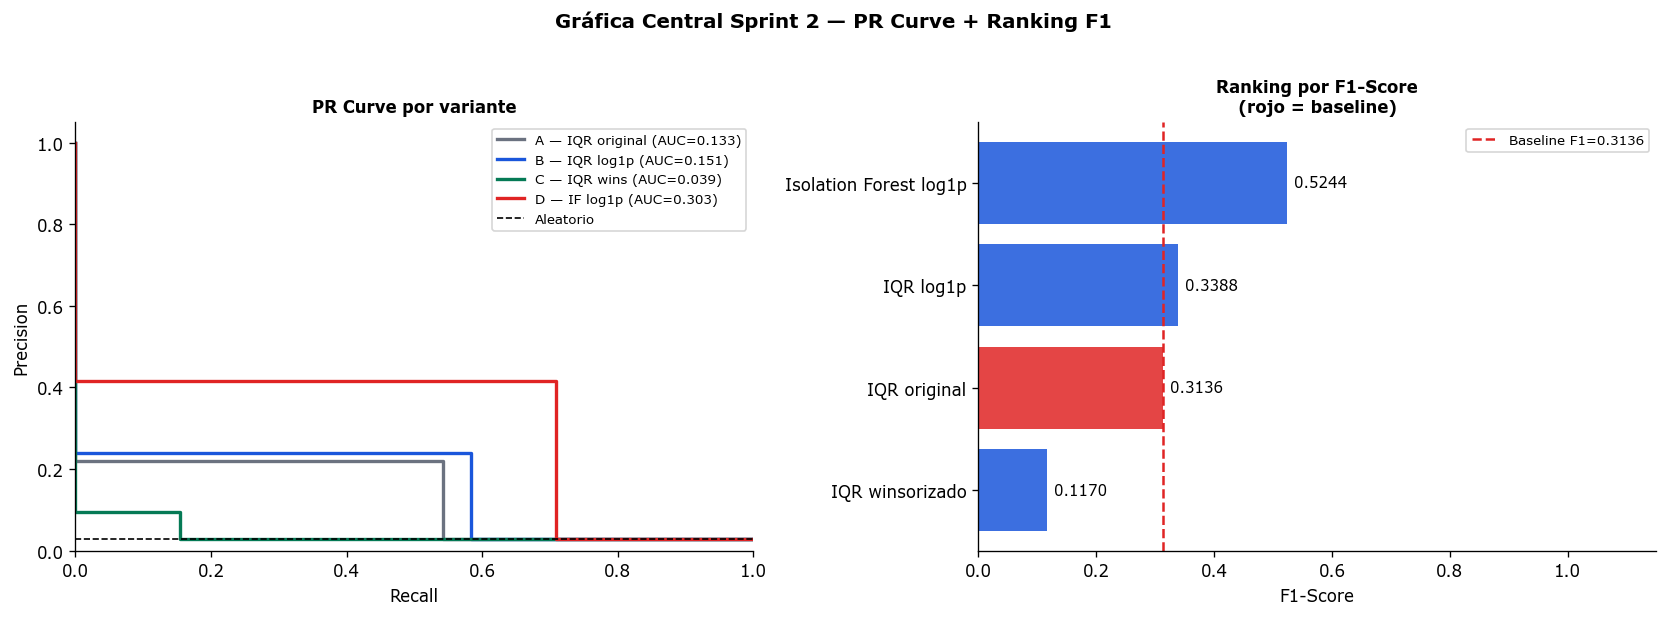

2026-05-08 19:00:38 | INFO | PR Curve guardada: fig_s2_pr_curve.png


In [31]:
# ── PR Curve por variante ──────────────────────────────────────────────────────
variantes_pr = [
    ('A — IQR original', pred_a, '#6b7280'),
    ('B — IQR log1p',    pred_b, '#1a56db'),
    ('C — IQR wins',     pred_c, '#057a55'),
    ('D — IF log1p',     pred_d, '#e02424'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR Curves
for nombre, pred, color in variantes_pr:
    pr, rc, _ = precision_recall_curve(y_true, pred)
    auc_v     = average_precision_score(y_true, pred)
    axes[0].step(rc, pr, where='post', color=color, linewidth=2,
                 label=f'{nombre} (AUC={auc_v:.3f})')

axes[0].axhline(y_true.mean(), color='black', linestyle='--', linewidth=1, label='Aleatorio')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('PR Curve por variante', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])

# Ranking F1
modelos = tabla_resultados['Modelo'].tolist()
f1s     = tabla_resultados['F1'].tolist()
colores = ['#e02424' if v == 'A' else '#1a56db' for v in tabla_resultados['Variante']]

bars = axes[1].barh(modelos[::-1], f1s[::-1], color=colores[::-1], alpha=0.85)
axes[1].bar_label(bars, fmt='%.4f', padding=4, fontsize=9)
axes[1].axvline(baseline_f1, color='#e02424', linestyle='--', linewidth=1.5,
                label=f'Baseline F1={baseline_f1:.4f}')
axes[1].set_xlim(0, 1.15)
axes[1].set_xlabel('F1-Score')
axes[1].set_title('Ranking por F1-Score\n(rojo = baseline)', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Gráfica Central Sprint 2 — PR Curve + Ranking F1',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_s2_pr_curve.png', dpi=120, bbox_inches='tight')
plt.show()
log.info('PR Curve guardada: fig_s2_pr_curve.png')

---
## Sección 8 — Reproducibilidad
`logs/metrics_experimentos.csv` — trazabilidad de todos los experimentos

In [32]:
# ── Guardar log CSV ────────────────────────────────────────────────────────────
tabla_resultados['Sprint'] = 'Sprint2_Semana5'
tabla_resultados['Seed']   = SEED
tabla_resultados['FEC_INI']= FEC_INI
tabla_resultados['FEC_FIN']= FEC_FIN

modo = 'a' if LOG_CSV.exists() else 'w'
tabla_resultados.to_csv(LOG_CSV, mode=modo, index=False,
                        header=(modo == 'w'), encoding='utf-8')

print(f'Log guardado → {LOG_CSV}')
print(f'Filas acumuladas en log: {sum(1 for _ in open(LOG_CSV)) - 1}')
print()
print('Checklist de reproducibilidad:')
print(f'  ✓ Seed fijo          : {SEED}')
print(f'  ✓ Dataset versionado : EDA_BASE · {FEC_INI} → {FEC_FIN}')
print(f'  ✓ Split              : GroupKFold(5) grupos=NUM_SPN_R')
print(f'  ✓ FE fit en train    : percentiles winsorización calculados en train')
print(f'  ✓ Sin leakage        : ES_OUTLIER no usada en transformación')
print(f'  ✓ Log CSV            : {LOG_CSV}')
log.info('Log CSV guardado — %s', LOG_CSV)

2026-05-08 19:00:41 | INFO | Log CSV guardado — ..\..\logs\metrics_experimentos.csv


Log guardado → ..\..\logs\metrics_experimentos.csv
Filas acumuladas en log: 4

Checklist de reproducibilidad:
  ✓ Seed fijo          : 42
  ✓ Dataset versionado : EDA_BASE · 2024-01-01 → 2024-12-31
  ✓ Split              : GroupKFold(5) grupos=NUM_SPN_R
  ✓ FE fit en train    : percentiles winsorización calculados en train
  ✓ Sin leakage        : ES_OUTLIER no usada en transformación
  ✓ Log CSV            : ..\..\logs\metrics_experimentos.csv


---
## Sección 9 — Conclusión

In [33]:
# ── Conclusión estructurada según guía Semana 5 ───────────────────────────────
mejor_var   = tabla_resultados.iloc[0]
segunda_var = tabla_resultados.iloc[1]

print('=' * 70)
print('  CONCLUSIÓN SPRINT 2 — Feature Engineering + A/B Testing')
print('  Said Leonardo Uceda Paredes | UNI FIIS | Maestría en IA | Mayo 2026')
print('=' * 70)

print(f'''
  FEATURE QUE MÁS APORTÓ
  ───────────────────────
  Variante ganadora : {mejor_var["Variante"]} — {mejor_var["Modelo"]}
  F1 obtenido       : {mejor_var["F1"]}  (baseline A={baseline_f1})
  Mejora vs baseline: {mejor_var["Mejora_vs_A"]}
  PR-AUC            : {mejor_var["PR_AUC"]}

  El principal aporte viene de la transformación log1p: reduce el sesgo
  de la distribución (skew {datos.skew():.2f} → más simétrico), permitiendo
  que el IQR delimite mejor las colas reales de cada subpartida.
''')

print(f'''
  DECISIÓN
  ────────
  → ADOPTAR variante {mejor_var["Variante"]} ({mejor_var["Modelo"]}) como nuevo baseline.
  → Mantener contaminación=0.05 global; evaluar por sector en Sprint 3.
  → Excluir subpartidas < {UMBRAL_ANUAL} reg/año del modelo principal.
''')



print('=' * 70)
log.info('Conclusión Sprint 2 generada — ganador=%s F1=%.4f', mejor_var['Modelo'], mejor_var['F1'])

2026-05-08 19:00:44 | INFO | Conclusión Sprint 2 generada — ganador=Isolation Forest log1p F1=0.5244


  CONCLUSIÓN SPRINT 2 — Feature Engineering + A/B Testing
  Said Leonardo Uceda Paredes | UNI FIIS | Maestría en IA | Mayo 2026

  FEATURE QUE MÁS APORTÓ
  ───────────────────────
  Variante ganadora : D — Isolation Forest log1p
  F1 obtenido       : 0.5244  (baseline A=0.3136)
  Mejora vs baseline: 67.2%
  PR-AUC            : 0.3034

  El principal aporte viene de la transformación log1p: reduce el sesgo
  de la distribución (skew -1.30 → más simétrico), permitiendo
  que el IQR delimite mejor las colas reales de cada subpartida.


  DECISIÓN
  ────────
  → ADOPTAR variante D (Isolation Forest log1p) como nuevo baseline.
  → Mantener contaminación=0.05 global; evaluar por sector en Sprint 3.
  → Excluir subpartidas < 36 reg/año del modelo principal.

